# Twitter Sentiment Classification: Positive - Neutral - Negative

In [19]:
import pandas as pd

df_train = pd.read_csv('twitter_sentiment_train.csv')
df_test  = pd.read_csv('twitter_sentiment_test.csv')

In [20]:
int_to_label = {2: 'Positive', 1: 'Neutral', 0: 'Negative'}

In [21]:
df_train.head(2)

,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1


In [22]:
y_train=df_train.pop('label')
y_test=df_test.pop('label')

### Feature Extraction

In [23]:
import string, re, nltk
from math import log
from ekphrasis.classes.tokenizer import SocialTokenizer
from nltk.tag import pos_tag
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
tokenizer = SocialTokenizer(lowercase=False).tokenize

# 1. Frequency of each punctuation mark
def count_punctuation(text: str) -> dict:
    """
    Counts the occurrences of each punctuation mark in a given text.
    Returns: {'punctuation_char1': count1, 'punctuation_char2': count2, ...}
    """
    counts={}
    for punct in string.punctuation:
        counts[f"{punct}"]=0
    for c in text:
        if c in string.punctuation:
            counts[f"{c}"]+=1
    return counts


# 2. Natural logarithm of number of tokens in cleaned email
def log_number_of_tokens(text: str) -> dict:
    """
    Computes the natural logarithm of the number of tokens in the cleaned email.
    Returns: {'log_tokens': log_tokens}
    """
    tokens=tokenizer(text)
    if len(tokens) == 0:
        return {'log_tokens': 0}
    return {'log_tokens': log(len(tokens))}


# 3. Number of EMAILs contained in the message
def count_emails(text: str) -> dict:
    """
    Counts the number of EMAILs in a given text.
    Returns: {'email_count': count}
    """
    return {"email_count": len(re.findall(r'\b\S+@\S+\b', text))}

# 4. Number of capitalized tokens (first letter uppercase)
def count_capitalized_tokens(text: str) -> dict:
    """
    Counts the number of capitalized tokens (first letter uppercase) in a given text.
    Returns: {'capitalized_token_count': count}
    """
    tokens=tokenizer(text)
    capital_count=0
    for token in tokens:
        if re.match(r'[A-Z][a-z]+', token):
            capital_count+=1
    return {"capitalized_token_count": capital_count}

# 5. Number of fully capitalized tokens (all letters uppercase)
def count_all_capital_tokens(text: str) -> dict:
    """
    Counts the number of fully capitalized tokens (all letters uppercase) in a given text.
    Returns: {'all_capital_token_count': count}
    """
    tokens=tokenizer(text)
    all_capital_count=0
    for token in tokens:
        if re.fullmatch(r'[A-Z][A-Z]+', token):
            all_capital_count+=1
    return {"all_capital_token_count": all_capital_count}


# 6. Part-of-speech counts (adjectives, verbs, and nouns)
def count_pos(text: str) -> dict:
    """
    Counts the number of adjectives, verbs, and nouns in a given text.
    Returns: {'adjectives_count': count, 'verbs_count': count, 'nouns_count': count}
    """
    tokens=tokenizer(text)
    tags=pos_tag(tokens)
    tag_counts={'adjectives_count': 0, 'verbs_count': 0, 'nouns_count': 0}
    for _, tag in tags:
        # match tag at the start so following letters like 'P' for present are all included
        if re.match(r'JJ', tag):
            tag_counts['adjectives_count']+=1
        elif re.match(r'VB', tag):
            tag_counts['verbs_count']+=1
        elif re.match(r'NN', tag):
            tag_counts['nouns_count']+=1
    return tag_counts

# 7. Number of stopwords in the message
def count_stopwords(text: str) -> dict:
    """
    Counts the number of stopwords in the message.
    Returns: {'stopwords_count': count}
    """
    tokens=tokenizer(text)
    tokens=[token.lower() for token in tokens]
    stop_words = set(stopwords.words('english'))
    stopword_count=0
    for token in tokens:
        if token in stop_words:
            stopword_count+=1
    return {"stopwords_count": stopword_count}
    

# 9. Length of quoted content
def quoted_length(text: str) -> dict:
    """
    Counts the length of quoted content (number of lines).
    Returns: {'quoted_length': length}
    """
    return {'quoted_length': len(re.findall(r"^>",text, flags=re.MULTILINE))}

# 10. Maximum depth of quoted content
def max_quote_depth(text: str) -> dict:
    """
    Finds the maximum depth of quoted content (maximum number of nested quotes).
    Returns: {'max_quote_depth': length}
    """
    quotes=re.findall(r"^>+",text, flags=re.MULTILINE)
    if len(quotes) == 0:
        return {'max_quote_depth': 0}
    quote_depths=[len(quote) for quote in quotes]
    return {'max_quote_depth': max(quote_depths)}

# 11. Existence of signature
def signature_exitence(text:str) -> dict:
    """
    Identifies the existence of signature in the email.
    Returns: {'signature_existence': 1 or 0}
    """
    signatures=len(re.findall(r'^(--|~~|==)', text, flags=re.MULTILINE))
    return {'signature_existence': 1 if signatures>0 else 0}

/home/neofytos/nlp/.venv/lib/python3.12/site-packages/ekphrasis/classes/tokenizer.py:225: FutureWarning: Possible nested set at position 2190
  self.tok = re.compile(r"({})".format("|".join(pipeline)))


#### Preprocessing Pipeline

In [24]:
from nltk.corpus import stopwords
nltk.download('stopwords')

nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/neofytos/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/neofytos/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/neofytos/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [25]:
def uncontract(text):
    text = re.sub(r"(\b)([Aa]re|[Cc]ould|[Dd]id|[Dd]oes|[Dd]o|[Hh]ad|[Hh]as|[Hh]ave|[Ii]s|[Mm]ight|[Mm]ust|[Ss]hould|[Ww]ere|[Ww]ould)n't", r"\1\2 not", text)
    text = re.sub(r"(\b)([Hh]e|[Ii]|[Ss]he|[Tt]hey|[Ww]e|[Ww]hat|[Ww]ho|[Yy]ou)'ll", r"\1\2 will", text)
    text = re.sub(r"(\b)([Tt]hey|[Ww]e|[Ww]hat|[Ww]ho|[Yy]ou)'re", r"\1\2 are", text)
    text = re.sub(r"(\b)([Ii]|[Ss]hould|[Tt]hey|[Ww]e|[Ww]hat|[Ww]ho|[Ww]ould|[Yy]ou)'ve", r"\1\2 have", text)

    text = re.sub(r"(\b)([Cc]a)n't", r"\1\2n not", text)
    text = re.sub(r"(\b)([Ii])'m", r"\1\2 am", text)
    text = re.sub(r"(\b)([Ll]et)'s", r"\1\2 us", text)
    text = re.sub(r"(\b)([Ii]t)'s", r"\1\2 is", text)
    text = re.sub(r"(\b)([Tt]here)'s", r"\1\2 is", text)
    text = re.sub(r"(\b)([Ww])on't", r"\1\2ill not", text)
    text = re.sub(r"(\b)([Ss])han't", r"\1\2hall not", text)
    text = re.sub(r"(\b)([Yy])(?:'all|a'll)", r"\1\2ou all", text)

    return text


def tokenize_text(text):
    tokens = tokenizer(text)

    return tokens


def lowercase_tokens(tokens):
    tokens = [t.lower() for t in tokens]

    return tokens


def remove_stopwords(tokens):
    stop_words = stopwords.words('english')

    tokens = [t for t in tokens if t not in stop_words]

    return tokens


def lemmatize(tokens):
    lemmatizer = WordNetLemmatizer()

    lemmatized = [lemmatizer.lemmatize(t) for t in tokens]

    return lemmatized
 
def preprocessing_text(text):
   text = uncontract(text)
   text = tokenize_text(text)
   text = lowercase_tokens(text)
   text = remove_stopwords(text)
   text = lemmatize(text)

   return text

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Preprocess
clean_train_tweet_tokens=[tokenize_text(text) for text in df_train['text']]
clean_train_tweet_tokens=[lowercase_tokens(tokens) for tokens in clean_train_tweet_tokens]
clean_train_tweet_tokens=[remove_stopwords(tokens) for tokens in clean_train_tweet_tokens]
clean_train_tweet_tokens=[lemmatize(tokens) for tokens in clean_train_tweet_tokens]

clean_tweet_text_train = [' '.join(tokens) for tokens in clean_train_tweet_tokens]

# Train TF-IDF model on preprocessed training data
tfidf_vectorizer = TfidfVectorizer(
   ngram_range  = (1,1),
   max_features = 300,
   lowercase    = False,
   tokenizer    = None,
   preprocessor = None,
   stop_words   = None,
   min_df       = 10,
   max_df       = 0.80
)
tfidf_vectorizer.fit_transform(clean_tweet_text_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 218923 stored elements and shape (45615, 300)>

In [27]:
from sklearn.feature_extraction.text import CountVectorizer

def get_tfidf_matrix(texts: list[str], vectorizer: CountVectorizer) -> dict:
    """
    Takes a text string and a fitted CountVectorizer,
    and returns a dictionary with all n-grams in the vectorizer’s vocabulary as keys
    and their corresponding frequencies (counts) in the input text as values.

    Example:
    ----------
    Suppose your fitted vectorizer learned the following vocabulary:
        ["win", "best", "birthday gift", "please call"]

    Input text:
        "Please call now to win a gift! Please call again!"

    Returned dictionary:
        {
          "win": 1,
          "best": 0,
          "birthday gift": 0,
          "please call": 2
        }

    → Words or bigrams not found in the text have a count of 0.
    """
    # Apply preprocessing to text
    texts=[tokenize_text(text) for text in texts]
    texts=[lowercase_tokens(text) for text in texts]
    texts=[remove_stopwords(text) for text in texts]
    texts=[lemmatize(text) for text in texts]

    texts = [' '.join(text) for text in texts]
    
    tfidf_matrix = vectorizer.transform(texts)

    return tfidf_matrix

In [ ]:
from tqdm import tqdm
X_train=df_train.copy()
X_test=df_test.copy()
"""
This block extracts multiple types of text-based features from the dataset (X_train and X_test)
by applying a list of feature-extraction functions one by one.

1. The list 'feature_functions' defines all feature extractors to be applied.
   Each function takes an email as input and returns dictionary of features (e.g., POS tag counts, n-gram frequencies).

2. The for-loop iterates through each feature extraction function with a progress bar (tqdm).

3. For each function:
      • Apply it to every email in X_train['text'], storing results as a list of dicts.
      • Convert the results to a temporary DataFrame (temp_df).
      • Reset indices and horizontally concatenate (pd.concat) the new features
        to X_train — effectively expanding the dataset with new columns.
      • Repeat the same process for X_test.

After this loop finishes:
      X_train and X_test contain both the original text column ('text')
      and all derived numeric and categorical features ready for modeling.
"""
feature_functions = [
    count_punctuation,
    log_number_of_tokens,
    count_emails,
#     count_capitalized_tokens,
#     count_all_capital_tokens,
#     count_pos,
#     count_stopwords,
    quoted_length,
    max_quote_depth,
    signature_exitence,
#     lambda text: get_tfidf_matrix(text, tfidf_vectorizer)
]

for func in tqdm(feature_functions):
    results = X_train['text'].apply(lambda x: func(str(x))).tolist()
    temp_df = pd.DataFrame(results)

    temp_df.reset_index(drop=True, inplace=True)
    X_train.reset_index(drop=True, inplace=True)
    X_train = pd.concat([X_train, temp_df], axis=1)

    results = X_test['text'].apply(lambda x: func(str(x))).tolist()
    temp_df = pd.DataFrame(results)

    temp_df.reset_index(drop=True, inplace=True)
    X_test.reset_index(drop=True, inplace=True)
    X_test = pd.concat([X_test, temp_df], axis=1)

texts = X_train['text'].astype(str).tolist()

tfidf_matrix = get_tfidf_matrix(X_train['text'], tfidf_vectorizer)
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

X_train = pd.concat([X_train.reset_index(drop=True), tfidf_df], axis=1)

texts = X_test['text'].astype(str).tolist()

tfidf_matrix = get_tfidf_matrix(X_test['text'], tfidf_vectorizer)
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

X_test = pd.concat([X_test.reset_index(drop=True), tfidf_df], axis=1)

  0%|          | 0/6 [00:00<?, ?it/s]

 17%|█▋        | 1/6 [00:00<00:03,  1.54it/s]

In [ ]:
X_train.head(10)

,text,!,"""",#,$,%,&,',(,),...,wish,woman,work,world,would,wwe,year,yes,yet,zayn
0,"""QT @user In the original draft of the 7th boo...",0,2,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,"""Ben Smith / Smith (concussion) remains out of...",0,2,2,0,0,0,0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,Sorry bout the stream last night I crashed out...,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,Chase Headley's RBI double in the 8th inning o...,0,0,0,0,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,@user Alciato: Bee will invest 150 million in ...,0,1,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
5,@user LIT MY MUM 'Kerry the louboutins I wonde...,4,0,0,0,0,0,2,0,0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
6,"""\"""""""" SOUL TRAIN\"""""""" OCT 27 HALLOWEEN SPECIA...",0,10,0,2,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
7,So disappointed in wwe summerslam! I want to s...,1,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.471978,0.0,0.0,0.0,0.0
8,"""This is the last Sunday w/o football .....,NF...",0,2,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
9,@user @user CENA & AJ sitting in a tree K-I-S-...,0,0,0,0,0,1,2,0,0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


Text(0.5, 1.0, 'Top k by importance')

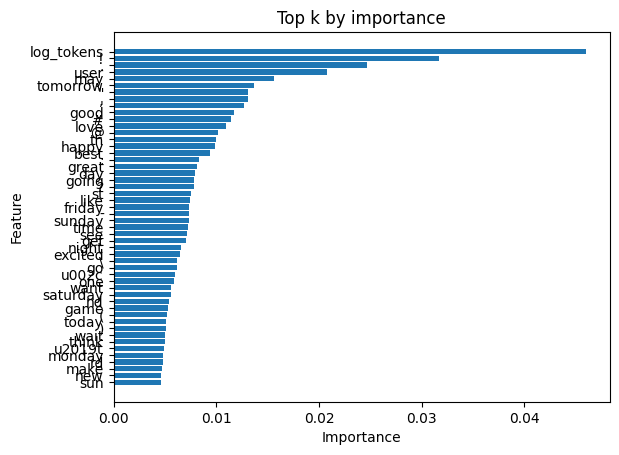

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
X_train_dropped = X_train.drop(columns=["text"])
X_test_dropped = X_test.drop(columns=["text"])

model = RandomForestClassifier(n_estimators=100, random_state=123)
model.fit(X_train_dropped, y_train)

importances = model.feature_importances_

feature_importances = pd.DataFrame({
    'feature': X_train_dropped.columns,
    'importance': importances
})

sorted_feature_importances=feature_importances.sort_values(by="importance", ascending=False)

topk = sorted_feature_importances.head(50)

# Top k plot
plt.figure()
plt.barh(topk["feature"], topk["importance"])
# Highest value at the top
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top k by importance")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD, Adam
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1774603304.058417    6638 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774603304.461099    6638 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774603308.264177    6638 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
import numpy as np

model_nn = Sequential([
    Dense(32, input_dim=X_train_dropped.shape[1], activation='relu'),   # hidden layer
    Dense(3, activation='softmax')                              # output layer
])

model_nn.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
model_nn.fit(X_train_dropped, y_train, epochs=20, batch_size=32, verbose=1)

# Predict
y_pred_prob_nn = model_nn.predict(X_test_dropped)
y_pred_nn = np.argmax(y_pred_prob_nn, axis=1) 

# Evaluate
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))

/home/neofytos/nlp/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1774603309.052843    6638 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/20


W0000 00:00:1774603310.837572    6638 cpu_allocator_impl.cc:82] Allocation of 61489020 exceeds 10% of free system memory.


1426/1426 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.5148 - loss: 0.9913
Epoch 2/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5328 - loss: 0.9681
Epoch 3/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5420 - loss: 0.9575
Epoch 4/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5495 - loss: 0.9481
Epoch 5/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5619 - loss: 0.9392
Epoch 6/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5669 - loss: 0.9302
Epoch 7/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5738 - loss: 0.9213
Epoch 8/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5788 - loss: 0.9131
Epoch 9/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5824 - loss: 0.9047
Epoch 10/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5876 - loss: 0.8974
Epoch 11/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5903 - loss: 0.8910
Epoch 12/20
1426/1426 ━━━━━━━━━━━━━━━━━━━

W0000 00:00:1774603370.079076    6638 cpu_allocator_impl.cc:82] Allocation of 16558832 exceeds 10% of free system memory.


384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Neural Network Accuracy: 0.5280853142298926


In [ ]:
model_nn_topk = Sequential([
    Dense(32, input_dim=X_train_dropped[topk].shape[1], activation='relu'),   # hidden layer
    Dense(3, activation='softmax')                              # output layer
])

model_nn_topk.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
model_nn_topk.fit(X_train_dropped[topk], y_train, epochs=20, batch_size=32, verbose=1)

# Predict
y_pred_prob_nn = model_nn_topk.predict(X_test_dropped[topk])
y_pred_nn = np.argmax(y_pred_prob_nn, axis=1) 

# Evaluate
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))

/home/neofytos/nlp/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


W0000 00:00:1774603375.514382    6638 cpu_allocator_impl.cc:82] Allocation of 61489020 exceeds 10% of free system memory.


1426/1426 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1555 - loss: nan
Epoch 2/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1555 - loss: nan
Epoch 3/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1555 - loss: nan
Epoch 4/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1555 - loss: nan
Epoch 5/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1555 - loss: nan
Epoch 6/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1555 - loss: nan
Epoch 7/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1555 - loss: nan
Epoch 8/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1555 - loss: nan
Epoch 9/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1555 - loss: nan
Epoch 10/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1555 - loss: nan
Epoch 11/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1555 - loss: nan
Epoch 12/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1555 

W0000 00:00:1774603435.251561    6638 cpu_allocator_impl.cc:82] Allocation of 16558832 exceeds 10% of free system memory.


384/384 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Neural Network Accuracy: 0.32334744382937153
